# Notebook 09 — Kohn-Sham Density Functional Theory

**MOLEKUL | Phase 12**

---

**Density Functional Theory** (DFT) is the workhorse of computational chemistry and
materials science. Unlike wavefunction methods, DFT works with the electron density
$\rho(\mathbf{r})$ — a function of only 3 coordinates, not $3N$ — making it dramatically
more efficient.

**What you will learn:**
1. The Hohenberg-Kohn theorems and why density determines everything.
2. The Kohn-Sham equations: KS orbitals and the XC potential.
3. LDA (Slater exchange + VWN correlation) and GGA (PBE) functionals.
4. Numerical integration grids: Becke atom-centred grids.
5. Comparing DFT (LDA, PBE) vs. HF on energies, geometries, and dipoles.

## 1. The Hohenberg-Kohn theorems

**Theorem 1** (Hohenberg & Kohn 1964): The external potential $v(\mathbf{r})$
(and hence all ground-state properties) is uniquely determined by the ground-state
electron density $\rho_0(\mathbf{r})$.

This means the total energy is a **functional** of the density:
$$E[\rho] = F[\rho] + \int v(\mathbf{r})\rho(\mathbf{r})\,d^3r$$

**Theorem 2** (variational principle): $E[\rho] \geq E_0$ for all trial densities $\rho$,
with equality for the exact ground-state density.

### Kohn-Sham equations

Kohn and Sham (1965) introduced auxiliary non-interacting electrons in an effective potential
$v_s(\mathbf{r})$ chosen so that their density equals the interacting density $\rho$.
This maps the intractable interacting problem onto a tractable one:

$$\left[-\frac{1}{2}\nabla^2 + v_s(\mathbf{r})\right]\psi_i^{KS} = \varepsilon_i^{KS}\psi_i^{KS}$$

$$v_s(\mathbf{r}) = v_{\text{ext}}(\mathbf{r}) + v_J(\mathbf{r}) + v_{xc}(\mathbf{r})$$

where $v_{xc} = \delta E_{xc}/\delta\rho$ is the XC potential.

The total KS-DFT energy is:
$$E_{KS} = T_s[\rho] + E_J[\rho] + E_{xc}[\rho] + E_{ne}[\rho] + E_{nn}$$

where $T_s$ is the KS kinetic energy and $E_{xc}$ contains all exchange-correlation effects.

**Exact vs. approximate:** The theorems guarantee an exact $E_{xc}[\rho]$ exists, but
its form is unknown. All practical DFT calculations use approximations to $E_{xc}$.

In [1]:
# --- Make the MOLEKUL package importable -------------------------------
# Best practice: install once from the repo root with
#     pip install -e ".[notebooks]"
# The fallback below locates the in-repo src/ automatically, so the
# notebook also runs from a fresh clone that has not been installed yet,
# regardless of which directory Jupyter was started from.
try:
    import molekul  # noqa: F401
except ModuleNotFoundError:
    import sys, pathlib
    for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_p / "src" / "molekul").is_dir():
            sys.path.insert(0, str(_p / "src"))
            break
    import molekul  # noqa: F401
# -----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from molekul.atoms import Atom
from molekul.molecule import Molecule
from molekul.basis_sto3g import STO3G
from molekul.basis_631gstar import G631Star
from molekul.rhf import rhf_scf
from molekul.dft import ks_scf, eval_xc, build_grid, eval_basis_on_grid, eval_density
from molekul.constants import HARTREE_TO_KCAL_MOL, HARTREE_TO_EV

h2o = Molecule(
    atoms=[
        Atom.from_angstrom("O",  0.0000,  0.0000,  0.1173),
        Atom.from_angstrom("H",  0.7572,  0.0000, -0.4692),
        Atom.from_angstrom("H", -0.7572,  0.0000, -0.4692),
    ],
    name="water",
)
print("Ready.")

Ready.


## 2. The XC functionals implemented in MOLEKUL

### LDA (Local Density Approximation)

LDA assumes the XC energy density at each point equals that of the uniform electron gas
at the local density:
$$E_{xc}^{\text{LDA}}[\rho] = \int \rho(\mathbf{r})\,\varepsilon_{xc}(\rho(\mathbf{r}))\,d^3r$$

MOLEKUL implements:
- **Slater exchange (X-alpha):** $\varepsilon_x(\rho) = -\frac{3}{4}\left(\frac{3}{\pi}\right)^{1/3}\rho^{1/3}$
- **VWN5 correlation** (Vosko, Wilk, Nusair 1980): parametrisation of quantum Monte Carlo data.

LDA tends to overbind (underestimates bond lengths), but captures molecular trends.

### GGA — PBE

GGA (Generalised Gradient Approximation) adds dependence on the gradient $|\nabla\rho|$:
$$E_{xc}^{\text{GGA}}[\rho] = \int \rho(\mathbf{r})\,\varepsilon_{xc}(\rho,|\nabla\rho|)\,d^3r$$

**PBE** (Perdew-Burke-Ernzerhof 1996) satisfies several exact constraints and is the most
widely used GGA functional. It corrects LDA's overbinding.

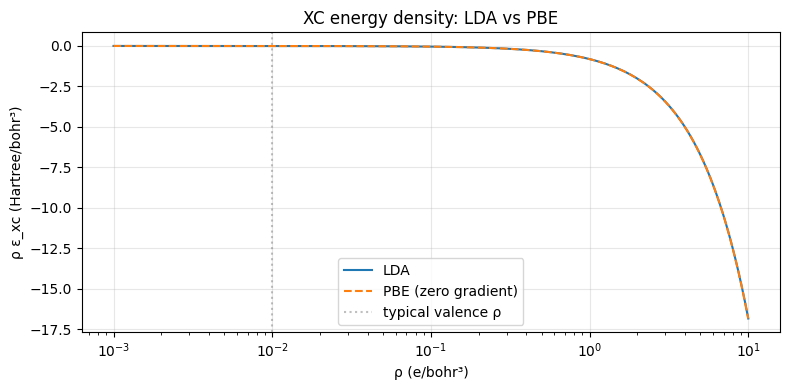

In [2]:
rho = np.logspace(-3, 1, 200)
sigma = np.zeros_like(rho)

eps_lda, _, _ = eval_xc('lda', rho, sigma)
eps_pbe, _, _ = eval_xc('pbe', rho, sigma)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(rho, rho * eps_lda, label='LDA')
ax.semilogx(rho, rho * eps_pbe, '--', label='PBE (zero gradient)')
ax.axvline(0.01, ls=':', color='gray', alpha=0.5, label='typical valence \u03c1')
ax.set_xlabel('\u03c1 (e/bohr\u00b3)')
ax.set_ylabel('\u03c1 \u03b5_xc (Hartree/bohr\u00b3)')
ax.set_title('XC energy density: LDA vs PBE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Numerical integration grid

The XC energy requires a numerical integral over all space. MOLEKUL uses
**Becke's atom-centred partitioning** (1988):

1. Build a grid around each atom (radial × angular product).
2. Assign Becke partition weights $w_A(\mathbf{r})$ so that $\sum_A w_A(\mathbf{r}) = 1$.
3. The molecular integral becomes a sum over atom-centred contributions.

**Radial grid:** Gauss-Chebyshev type 2 with a Mura-Knowles radial mapping that
concentrates points near the nucleus (where density is largest).

**Angular grid:** Product Gauss-Legendre (latitude) × uniform (longitude).

MOLEKUL defaults: 75 radial × 302 angular ≈ 22,650 points per atom.

In [3]:
basis = STO3G

# Build grid for water
grid_coords, grid_weights = build_grid(h2o, n_rad=75, n_ang=302)
print(f"Grid size: {len(grid_coords)} points  ({len(grid_coords)/h2o.n_atoms:.0f} per atom)")

# Run RHF to get a density matrix for testing
rhf_res = rhf_scf(h2o, basis)
phi = eval_basis_on_grid(basis, h2o, grid_coords)  # (n_pts, n_basis)
rho_grid = eval_density(rhf_res.density_matrix, phi)  # (n_pts,)

# Integrate to check ∫ρ dV ≈ N_e
n_el_grid = np.dot(rho_grid, grid_weights)
print(f"∫ρ dV = {n_el_grid:.4f}  (expected {h2o.n_electrons})")

Grid size: 64800 points  (21600 per atom)


∫ρ dV = 10.0000  (expected 10)


## 4. Running KS-DFT calculations

In [4]:
print("Running KS-DFT/LDA for H₂O/STO-3G...")
lda_res = ks_scf(h2o, basis, xc="lda", verbose=True)

print(f"\nLDA energy: {lda_res.energy_total:.6f} Ha")
print(f"XC energy:  {lda_res.energy_xc:.6f} Ha")
print(f"Converged:  {lda_res.converged} in {lda_res.n_iter} iterations")

Running KS-DFT/LDA for H₂O/STO-3G...


  KS-DFT (LDA): building integration grid …
  Grid: 64800 points

Iter          E_total (Ha)             ΔE       ΔP_max
--------------------------------------------------------
   1        -72.9646865273  -7.296469e+01   2.2408e+00
   2        -73.9741866191  -1.009500e+00   1.6690e+00
   3        -74.2577069715  -2.835204e-01   7.8579e-01
   4        -74.7308005949  -4.730936e-01   5.1029e-02
   5        -74.7320144201  -1.213825e-03   1.3825e-03
   6        -74.7320149066  -4.865031e-07   1.7216e-04
   7        -74.7320149376  -3.099422e-08   3.0982e-05
   8        -74.7320149385  -8.389520e-10   3.4236e-07

  KS-DFT converged in 8 iterations
  E_total = -74.7320149385 Ha
  E_xc    = -8.8759371266 Ha

LDA energy: -74.732015 Ha
XC energy:  -8.875937 Ha
Converged:  True in 8 iterations


In [5]:
print("Running KS-DFT/PBE for H₂O/STO-3G...")
pbe_res = ks_scf(h2o, basis, xc="pbe", verbose=False)

print(f"PBE energy: {pbe_res.energy_total:.6f} Ha")
print(f"XC energy:  {pbe_res.energy_xc:.6f} Ha")

Running KS-DFT/PBE for H₂O/STO-3G...


PBE energy: -75.228101 Ha
XC energy:  -9.368092 Ha


> ⚠️ **PBE is experimental in MOLEKUL.** The LDA path (Slater exchange + VWN
> correlation) is validated against PySCF to ~$10^{-5}$ Ha. The PBE (GGA) path is
> implemented but **not** fully grid-converged: its gradient correction amplifies
> numerical grid error to the ~$10^{-3}$ Ha level (see `SCIENCE.md` → *"DFT Becke
> integration grid"* and the README feature table). Treat the PBE numbers in this
> notebook as illustrative, and rely on LDA for quantitative comparisons in this
> minimal STO-3G setup.

In [6]:
from molekul.mp2 import mp2_energy

# Reuse the RHF result computed earlier instead of re-running SCF three times.
rhf_e = rhf_res.energy_total
mp2_e = mp2_energy(h2o, basis, rhf_res).energy_total
lda_e = lda_res.energy_total
pbe_e = pbe_res.energy_total

# Reference total energies from PySCF 2.x, same geometry + STO-3G, grids.level=3
# (matches MOLEKUL's 75x302 Becke grid). To regenerate:
#   from pyscf import gto, dft
#   m = gto.M(atom="O 0 0 0.1173; H 0.7572 0 -0.4692; H -0.7572 0 -0.4692",
#             basis="sto-3g")
#   ks = dft.RKS(m); ks.xc = "lda,vwn"   # or "pbe"
#   ks.grids.level = 3; print(ks.kernel())
pyscf_lda = -74.732039   # LDA (Slater + VWN) / STO-3G, grids.level=3
pyscf_pbe = -75.225567   # PBE / STO-3G, grids.level=3  (experimental path)

print(f"{'Method':10s}  {'E (Ha)':>14}  {'vs PySCF':>14}")
print("-" * 44)
print(f"{'HF':10s}  {rhf_e:>14.6f}")
print(f"{'MP2':10s}  {mp2_e:>14.6f}")
print(f"{'LDA':10s}  {lda_e:>14.6f}  {lda_e-pyscf_lda:>+14.2e} Ha")
print(f"{'PBE':10s}  {pbe_e:>14.6f}  {pbe_e-pyscf_pbe:>+14.2e} Ha  (experimental)")

# LDA agrees with PySCF to ~1e-5 Ha (validated); PBE differs by ~1e-3 Ha because the
# GGA gradient term is sensitive to the numerical grid (the experimental caveat above).

Method              E (Ha)        vs PySCF
--------------------------------------------
HF              -74.963023
MP2             -74.998569
LDA             -74.732015       +2.41e-05 Ha
PBE             -75.228101       -2.53e-03 Ha  (experimental)


## 5. KS vs. HF orbital energies

KS orbital energies are NOT the same as HF orbital energies and should not be
interpreted the same way. The only KS orbital with a rigorous physical meaning
is the HOMO, which equals the negative ionisation potential
(Janak's theorem, the DFT analogue of Koopmans').

In [7]:
# KS and HF orbital energies side by side (reusing results already computed).
n_occ = h2o.n_electrons // 2
eps_hf  = rhf_res.mo_energies * HARTREE_TO_EV
eps_lda = lda_res.mo_energies * HARTREE_TO_EV
eps_pbe = pbe_res.mo_energies * HARTREE_TO_EV

print(f"{'MO':>4}  {'HF e (eV)':>12}  {'LDA e (eV)':>12}  {'PBE e (eV)':>12}")
print("-" * 47)
for i in range(len(eps_hf)):
    mark = " <- HOMO" if i == n_occ - 1 else " <- LUMO" if i == n_occ else ""
    print(f"{i+1:>4}  {eps_hf[i]:>12.4f}  {eps_lda[i]:>12.4f}  {eps_pbe[i]:>12.4f}{mark}")

  MO     HF e (eV)    LDA e (eV)    PBE e (eV)
-----------------------------------------------
   1     -550.8093     -497.1770     -501.8876
   2      -34.5085      -22.6092      -22.9382
   3      -16.8048      -10.4209      -10.5836
   4      -12.3274       -4.0677       -4.3987
   5      -10.6461       -1.5623       -1.7947 <- HOMO
   6       16.4676        8.6142        8.4311 <- LUMO
   7       20.1799       11.5840       11.4212


## 6. Visualising the XC potential

The XC potential $v_{xc}(\mathbf{r}) = \delta E_{xc}/\delta\rho$ is the key quantity
that distinguishes DFT from HF. For LDA:
$$v_x^{\text{LDA}}(\mathbf{r}) = -\left(\frac{3}{\pi}\right)^{1/3}\rho(\mathbf{r})^{1/3}$$

It is a local function of $\rho$ — entirely different from the non-local HF exchange.
This locality is why DFT scales as $\mathcal{O}(N^3)$ while exact exchange scales as $\mathcal{O}(N^4)$.

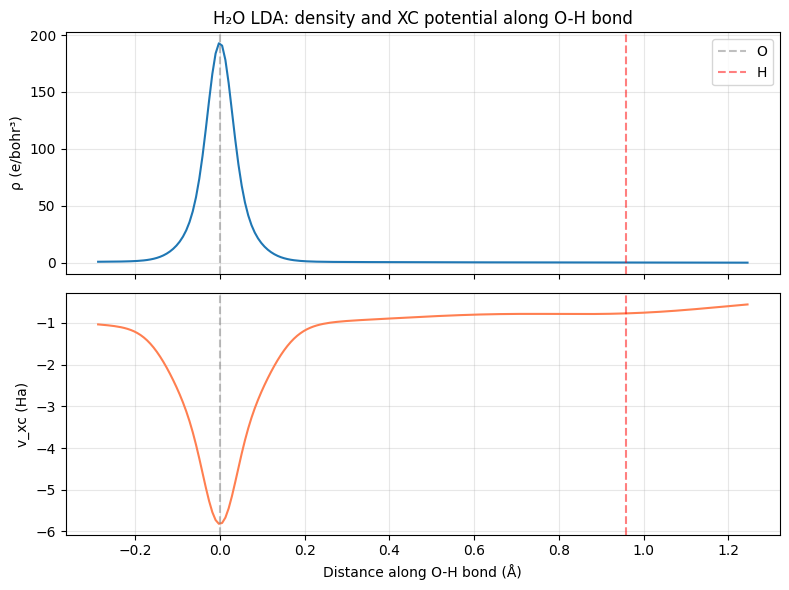

In [8]:
n_pts = 200
O_coords = h2o.atoms[0].coords
H_coords = h2o.atoms[1].coords
t = np.linspace(-0.3, 1.3, n_pts)
path = np.array([(1-ti)*O_coords + ti*H_coords for ti in t])

phi_path = eval_basis_on_grid(basis, h2o, path)
rho_path = eval_density(lda_res.density_matrix, phi_path)

eps_path, vxc_path, _ = eval_xc('lda', np.maximum(rho_path, 1e-20),
                                  np.zeros_like(rho_path))

from molekul.constants import BOHR_TO_ANGSTROM
bond_length = np.linalg.norm(H_coords - O_coords) * BOHR_TO_ANGSTROM
x_axis = t * bond_length

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(x_axis, rho_path)
ax1.set_ylabel('\u03c1 (e/bohr\u00b3)')
ax1.set_title('H\u2082O LDA: density and XC potential along O-H bond')
ax1.axvline(0, ls='--', color='gray', alpha=0.5, label='O')
ax1.axvline(bond_length, ls='--', color='red', alpha=0.5, label='H')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(x_axis, vxc_path, color='coral')
ax2.set_ylabel('v_xc (Ha)')
ax2.set_xlabel('Distance along O-H bond (\u00c5)')
ax2.axvline(0, ls='--', color='gray', alpha=0.5)
ax2.axvline(bond_length, ls='--', color='red', alpha=0.5)
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---

## Exercises

**1.** Run LDA and PBE for N₂/STO-3G and compare the total energies to HF.
DFT includes correlation whereas HF does not — do the DFT energies lie below or above HF?
Explain using the variational principle.

**2.** The LDA HOMO energy of H₂O should be close to the negative experimental IP (12.6 eV).
Compare LDA, PBE, and HF HOMO energies. Which is closest to experiment?

**3.** Integrate the XC energy density $\rho(\mathbf{r})\varepsilon_{xc}(\rho(\mathbf{r}))$
over the numerical grid and compare to `lda_res.energy_xc`. How accurate is the integration?

**4.** The grid accuracy can be tested by checking that $\int\rho d^3r = N_e$.
Vary `n_rad` from 20 to 100 and `n_ang` from 50 to 302. What is the minimum grid
that gives $|\int\rho - N_e| < 0.01$?

**5.** (Advanced) LDA over-delocalises electrons (overbinding) while HF under-delocalises
them. Compute the H-H bond length of H₂ optimised with HF/STO-3G vs. LDA/STO-3G.
Which is closer to experiment (0.741 Å)?

---

## Summary

| Concept | Key formula / note |
|---------|-------------------|
| Hohenberg-Kohn | $E[\rho]$ uniquely determined by ground-state density |
| Kohn-Sham | Non-interacting reference with $v_s = v_{ext} + v_J + v_{xc}$ |
| LDA | $E_{xc}[\rho] = \int\rho\,\varepsilon_{xc}^{\text{UEG}}(\rho)\,d^3r$; local |
| PBE | GGA: adds $|\nabla\rho|$ dependence; satisfies more exact constraints |
| Becke grid | Atom-centred product grid; 75 radial × 302 angular per atom |
| KS scaling | $\mathcal{O}(N^3)$ (like HF) for local functionals |
| HOMO | Only KS orbital with rigorous physical meaning ($=-$IP via Janak) |

DFT gives accuracy between MP2 and HF at HF computational cost for most ground-state properties.
Its limitation is the unknown exact $E_{xc}$ — the subject of ongoing functional development.